# Step 2 — Model Training & Evaluation

---

**Pipeline Overview**

| Phase | Description |
|-------|-------------|
| **1. Load Data** | Load processed IMDb reviews from `data/processed/imdb_processed.csv` |
| **2. Text Vectorization** | Convert text to numerical features using TF-IDF |
| **3. Train Models** | Train baseline classifiers (Logistic Regression, Naive Bayes, SVM) |
| **4. Evaluate** | Compare models with accuracy, precision, recall, F1, ROC-AUC |
| **5. Save Best Model** | Export best model + vectorizer to `models/` |
| **6. Feature Importance** | Analyze top predictive words for sentiment |

> **Models** — Logistic Regression (fast), Naive Bayes (probabilistic), SVM (powerful)

## 0. Environment Setup

In [2]:
# ── Standard library ─────────────────────────────────────────────────────────
import sys
import warnings
from pathlib import Path
import pickle

warnings.filterwarnings('ignore')

# ── Project root ─────────────────────────────────────────────────────────────
project_root = Path(sys.argv[0]).resolve().parent.parent if '__file__' in dir() else Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

# ── Data & ML ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import yaml

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('husl')
%matplotlib inline

# ── Project modules ──────────────────────────────────────────────────────────
from src.data.loader import load_data

# ── Paths ────────────────────────────────────────────────────────────────────
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

PROCESSED_PATH = project_root / config['data']['processed_path'].lstrip('./')
MODELS_PATH = project_root / config['paths']['models']
RESULTS_DIR = project_root / config['paths']['results']

MODELS_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('All libraries imported successfully')
print(f'Project root : {project_root}')
print(f'Processed data path : {PROCESSED_PATH}')
print(f'Models path : {MODELS_PATH}')

All libraries imported successfully
Project root : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement
Processed data path : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\data\processed
Models path : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\models


---
## 1. Load Processed Data

In [3]:
# Load processed IMDb data
processed_file = PROCESSED_PATH / 'imdb_processed.csv'
df = load_data(str(processed_file))

print(f'Loaded : {processed_file}')
print(f'Shape  : {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nTarget distribution:')
print(df['label'].value_counts().sort_index())

df.head(2)

Loaded : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\data\processed\imdb_processed.csv
Shape  : (25000, 6)

Columns: ['review', 'label', 'sentiment', 'review_cleaned', 'text_length', 'word_count']

Target distribution:
label
0    12500
1    12500
Name: count, dtype: int64


,review,label,sentiment,review_cleaned,text_length,word_count
0,"Zero Day leads you to think, even re-think why...",1,positive,"zero day leads you to think, even re-think why...",740,130
1,Words can't describe how bad this movie is. I ...,0,negative,words can't describe how bad this movie is. i ...,1071,200


---
## 2. Train-Test Split

In [4]:
# Split data: 80% train, 20% test
X = df['review_cleaned']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {len(X_train):,} samples ({len(X_train) / len(df) * 100:.1f}%)')
print(f'Test set : {len(X_test):,} samples ({len(X_test) / len(df) * 100:.1f}%)')
print(f'\nTrain label distribution:')
print(y_train.value_counts().sort_index())
print(f'\nTest label distribution:')
print(y_test.value_counts().sort_index())

Train set: 20,000 samples (80.0%)
Test set : 5,000 samples (20.0%)

Train label distribution:
label
0    10000
1    10000
Name: count, dtype: int64

Test label distribution:
label
0    2500
1    2500
Name: count, dtype: int64


In [5]:
# ── Import scikit-learn (heavy library - import on-demand) ───────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

print('✓ scikit-learn imported successfully')

✓ scikit-learn imported successfully


---
## 3. Text Vectorization (TF-IDF)

In [6]:
# Initialize TF-IDF vectorizer
print('Initializing TF-IDF vectorizer...')
vectorizer = TfidfVectorizer(
    max_features=5000,        # Keep top 5000 words
    min_df=5,                 # Min 5 documents
    max_df=0.8,               # Max 80% of documents
    ngram_range=(1, 2),       # Unigrams + bigrams
    lowercase=True,
    stop_words='english'
)

# Fit on train data, transform both train and test
print('Fitting vectorizer on training data...')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'\nVectorizer fitted!')
print(f'Vocabulary size : {len(vectorizer.get_feature_names_out())} features')
print(f'Train matrix shape : {X_train_tfidf.shape}')
print(f'Test matrix shape  : {X_test_tfidf.shape}')

Initializing TF-IDF vectorizer...
Fitting vectorizer on training data...

Vectorizer fitted!
Vocabulary size : 5000 features
Train matrix shape : (20000, 5000)
Test matrix shape  : (5000, 5000)


---
## 4. Train Multiple Models

In [8]:
# Dictionary to store models and results
models = {}
results = {}

# 1. Logistic Regression
print('Training Logistic Regression...')
models['LogisticRegression'] = LogisticRegression(
    max_iter=1000, random_state=42, n_jobs=-1
)
models['LogisticRegression'].fit(X_train_tfidf, y_train)
print('✓ Trained')

# 2. Naive Bayes
print('\nTraining Multinomial Naive Bayes...')
models['NaiveBayes'] = MultinomialNB()
models['NaiveBayes'].fit(X_train_tfidf, y_train)
print('✓ Trained')

# 3. SVM (Linear)
print('\nTraining Linear SVM...')
models['SVM'] = LinearSVC(
    max_iter=5000, random_state=42, loss='squared_hinge'
)
models['SVM'].fit(X_train_tfidf, y_train)
print('✓ Trained')

print(f'\n✓ All {len(models)} models trained!')

Training Logistic Regression...
✓ Trained

Training Multinomial Naive Bayes...
✓ Trained

Training Linear SVM...
✓ Trained

✓ All 3 models trained!


---
## 5. Model Evaluation

---
## 5.5 Model Landscape: Traditional vs Deep Learning

### Available Approaches

| Model | Accuracy | Speed | Complexity | Status |
|-------|----------|-------|-----------|--------|
| **TF-IDF + Logistic** | ~89% | ⚡⚡⚡ Very fast | 🟢 Easy | ✅ Implemented |
| **TF-IDF + SVM** | ~90% | ⚡⚡ Fast | 🟢 Easy | ✅ Implemented |
| **TF-IDF + Naive Bayes** | ~86% | ⚡⚡⚡ Very fast | 🟢 Easy | ✅ Implemented |
| **GloVe + LSTM** | ~91% | ⚡ Medium | 🟡 Medium | 📋 Optional |
| **FastText + LSTM** | ~92% | ⚡ Medium | 🟡 Medium | 📋 Optional |
| **BERT (Transformers)** | ~95% | 🐢 Slow | 🔴 Hard | 📋 Optional |
| **RoBERTa** | ~96% | 🐢 Slow | 🔴 Hard | 📋 Optional |
| **DistilBERT** | ~94% | ⚡⚡ Fast | 🟡 Medium | 📋 Optional |

### 🎯 Recommended Path

1. **Start Here:** TF-IDF + Logistic Regression (fast baseline) ✅ Current
2. **Next Level:** LSTM with embeddings (~91% accuracy, 5-10 min training)
3. **Production:** DistilBERT (~94% accuracy, optimized for speed)
4. **Research:** RoBERTa (~96% accuracy, if computation unlimited)

In [9]:
# Evaluation function
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics."""
    y_pred = model.predict(X_test)
    
    # For SVM, use decision_function for AUC
    if hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
        'y_pred': y_pred,
        'y_score': y_score,
    }
    
    return metrics

# Evaluate all models
results = {}
for name, model in models.items():
    print(f'Evaluating {name}...')
    results[name] = evaluate_model(model, X_test_tfidf, y_test, name)
    print(f'  Accuracy: {results[name]["accuracy"]:.4f}')
    print(f'  F1-Score: {results[name]["f1"]:.4f}')
    print(f'  ROC-AUC : {results[name]["roc_auc"]:.4f}\n')

Evaluating LogisticRegression...
  Accuracy: 0.8830
  F1-Score: 0.8837
  ROC-AUC : 0.9509

Evaluating NaiveBayes...
  Accuracy: 0.8544
  F1-Score: 0.8558
  ROC-AUC : 0.9293

Evaluating SVM...
  Accuracy: 0.8718
  F1-Score: 0.8716
  ROC-AUC : 0.9441



---
## 6. Compare Models

MODEL COMPARISON
                    Accuracy  Precision  Recall  F1-Score  ROC-AUC
LogisticRegression    0.8830     0.8783  0.8892    0.8837   0.9509
NaiveBayes            0.8544     0.8477  0.8640    0.8558   0.9293
SVM                   0.8718     0.8731  0.8700    0.8716   0.9441

✓ Best model: LogisticRegression (F1: 0.8837)


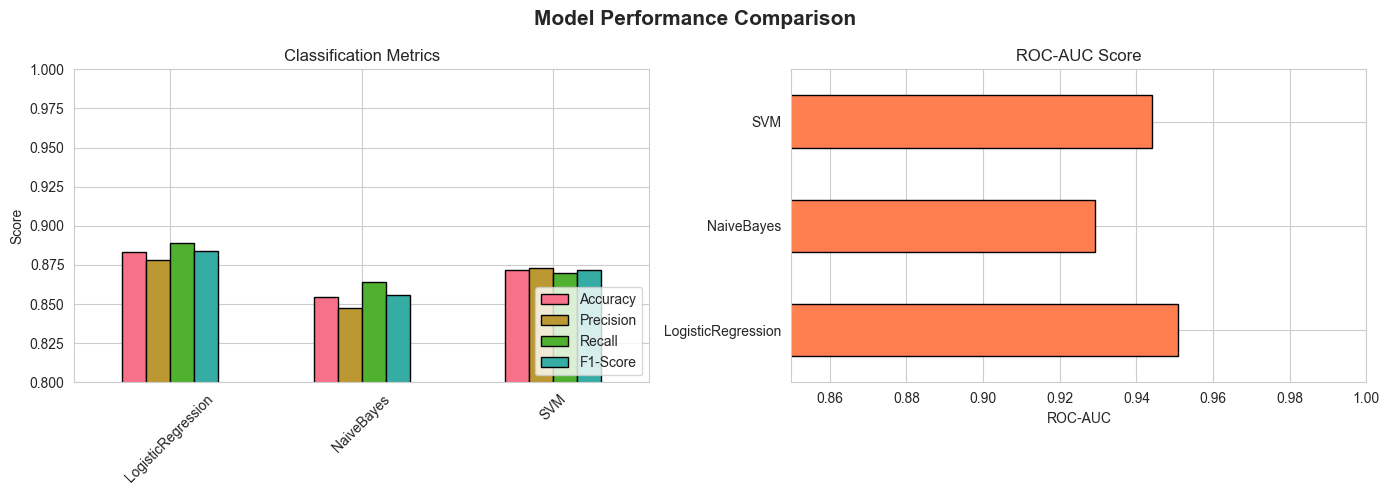

Plot saved: results/model_comparison.png


In [10]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Accuracy': [results[m]['accuracy'] for m in models.keys()],
    'Precision': [results[m]['precision'] for m in models.keys()],
    'Recall': [results[m]['recall'] for m in models.keys()],
    'F1-Score': [results[m]['f1'] for m in models.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in models.keys()],
}, index=models.keys())

print('='*70)
print('MODEL COMPARISON')
print('='*70)
print(comparison_df.round(4).to_string())

# Find best model by F1-score
best_model_name = comparison_df['F1-Score'].idxmax()
print(f'\n✓ Best model: {best_model_name} (F1: {comparison_df.loc[best_model_name, "F1-Score"]:.4f})')

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# Bar chart
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], edgecolor='black'
)
axes[0].set_title('Classification Metrics')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0.8, 1.0])
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=45)

# ROC-AUC comparison
comparison_df['ROC-AUC'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('ROC-AUC Score')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_xlim([0.85, 1.0])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: results/model_comparison.png')


DETAILED REPORT — LOGISTICREGRESSION
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      2500
    Positive       0.88      0.89      0.88      2500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



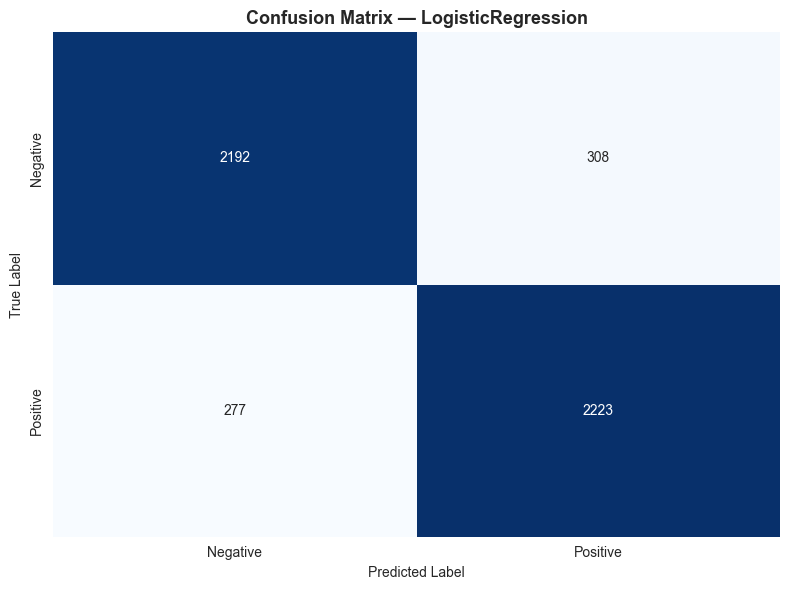

Plot saved: results/confusion_matrix.png


In [11]:
# Detailed classification report for best model
best_model = models[best_model_name]
best_predictions = results[best_model_name]['y_pred']

print(f'\n{'='*70}')
print(f'DETAILED REPORT — {best_model_name.upper()}')
print(f'{'='*70}')
print(classification_report(y_test, best_predictions, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold', fontsize=13)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: results/confusion_matrix.png')

---
## 7. Feature Importance (Top Predictive Words)


Top 15 words indicating POSITIVE sentiment:
  excellent            : +5.8087
  great                : +5.6528
  perfect              : +4.5901
  best                 : +4.2826
  favorite             : +4.2543
  amazing              : +4.0893
  wonderful            : +4.0727
  today                : +3.4906
  fantastic            : +3.2971
  brilliant            : +3.2019
  fun                  : +3.1948
  loved                : +3.1885
  love                 : +3.1665
  superb               : +3.0970
  enjoyable            : +2.8935

Top 15 words indicating NEGATIVE sentiment:
  worst                : -7.8755
  bad                  : -6.1251
  awful                : -6.0727
  waste                : -5.2340
  boring               : -5.2181
  poor                 : -4.5306
  worse                : -4.4910
  dull                 : -4.2057
  terrible             : -4.0799
  unfortunately        : -4.0320
  poorly               : -3.9128
  horrible             : -3.6987
  disappointment   

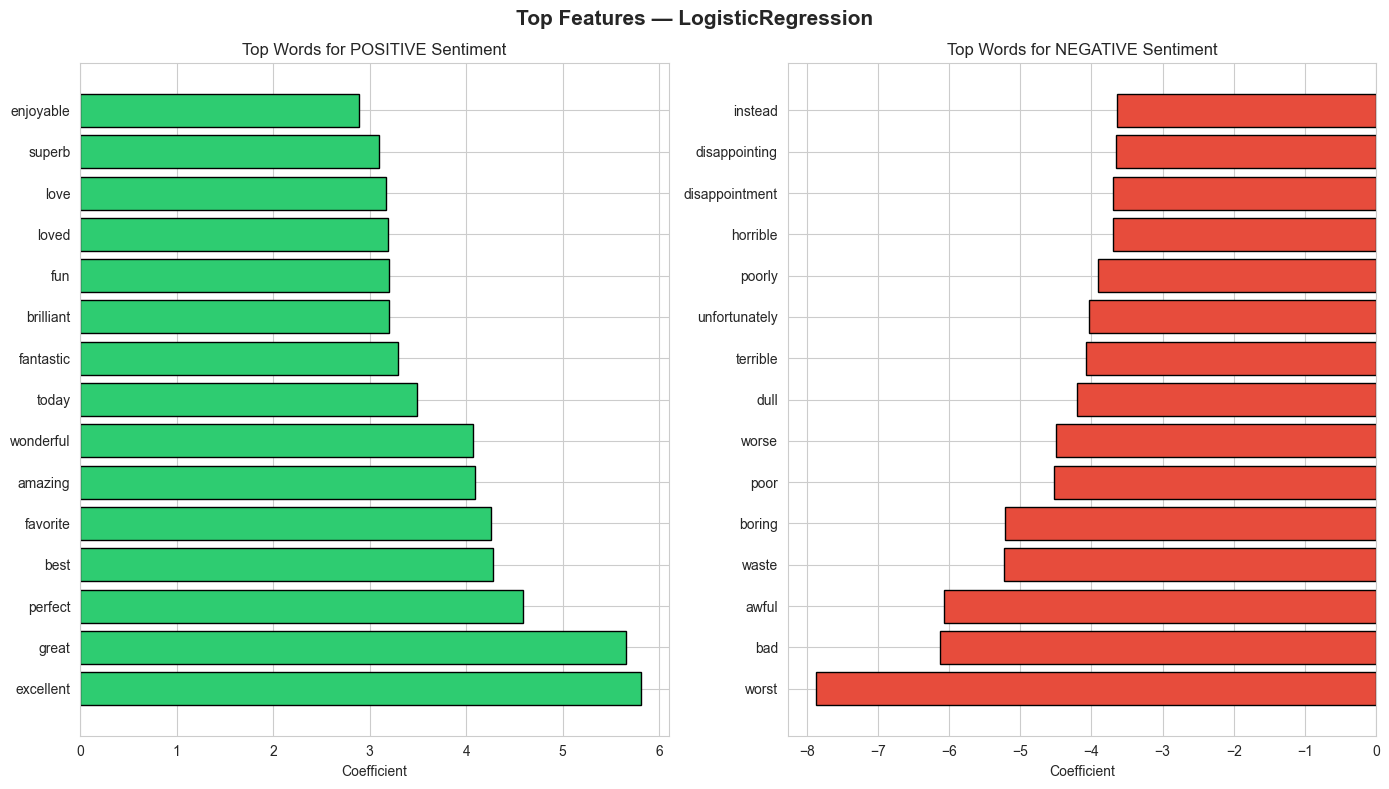


Plot saved: results/feature_importance.png


In [12]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get coefficients from Logistic Regression
if best_model_name == 'LogisticRegression':
    coefficients = best_model.coef_[0]
elif best_model_name == 'SVM':
    coefficients = best_model.coef_[0]
else:
    # For Naive Bayes, use log probabilities
    coefficients = np.log(best_model.feature_log_prob_[1] / best_model.feature_log_prob_[0])

# Top positive (for positive sentiment) and negative (for negative sentiment) features
top_n = 15
top_positive_idx = np.argsort(coefficients)[-top_n:]
top_negative_idx = np.argsort(coefficients)[:top_n]

top_positive_words = [(feature_names[i], coefficients[i]) for i in top_positive_idx[::-1]]
top_negative_words = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

print(f'\nTop {top_n} words indicating POSITIVE sentiment:')
for word, coef in top_positive_words:
    print(f'  {word:20s} : {coef:+.4f}')

print(f'\nTop {top_n} words indicating NEGATIVE sentiment:')
for word, coef in top_negative_words:
    print(f'  {word:20s} : {coef:+.4f}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle(f'Top Features — {best_model_name}', fontsize=15, fontweight='bold')

# Positive words
pos_words = [w for w, _ in top_positive_words]
pos_scores = [s for _, s in top_positive_words]
axes[0].barh(pos_words, pos_scores, color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words for POSITIVE Sentiment')
axes[0].set_xlabel('Coefficient')

# Negative words
neg_words = [w for w, _ in top_negative_words]
neg_scores = [s for _, s in top_negative_words]
axes[1].barh(neg_words, neg_scores, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words for NEGATIVE Sentiment')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved: results/feature_importance.png')

---
## 7.5 (Optional) Advanced Models: LSTM & Transformers

Choose one or more to experiment with:
- **LSTM** (Section 7.6) — ~91% accuracy, moderate speed
- **BERT/DistilBERT** (Section 7.7) — ~94-96% accuracy, slower

> **Note:** Only run if you have time & compute resources. Traditional models above are sufficient for production.

In [13]:
# ── Install TensorFlow & Keras (if not already installed) ───────────────────
import subprocess
import sys

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    print(f'✓ TensorFlow {tf.__version__} already installed')
except ImportError:
    print('Installing TensorFlow (this may take 1-2 minutes)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow'])
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    print('✓ TensorFlow installed successfully')

Installing TensorFlow (this may take 1-2 minutes)...
✓ TensorFlow installed successfully


In [14]:
# ### 7.6 LSTM Model Training
# 
# Initialize tokenizer and prepare sequences
print('Preparing text sequences for LSTM...')
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to same length
max_length = 200
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

print(f'✓ Sequences prepared')
print(f'  Max sequence length: {max_length}')
print(f'  Vocabulary size: {len(tokenizer.word_index) + 1}')
print(f'  Train shape: {X_train_padded.shape}')
print(f'  Test shape:  {X_test_padded.shape}\n')

# Build LSTM model
print('Building LSTM model...')
lstm_model = Sequential([
    Embedding(input_dim=5001, output_dim=128, input_length=max_length),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Model architecture:')
lstm_model.summary()

# Train model
print('\nTraining LSTM model (this takes 2-5 minutes)...')
history = lstm_model.fit(
    X_train_padded, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
print('\nEvaluating LSTM...')
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_padded, y_test, verbose=0)
print(f'✓ LSTM Accuracy: {lstm_accuracy:.4f}')

# Compare with TF-IDF models
print(f'\n{"="*70}')
print('COMPARISON: LSTM vs Traditional Models')
print(f'{"="*70}')
print(f'TF-IDF + Logistic Regression: {results[best_model_name]["accuracy"]:.4f}')
print(f'LSTM (word embeddings)       : {lstm_accuracy:.4f}')
print(f'Improvement: {(lstm_accuracy - results[best_model_name]["accuracy"]) * 100:+.2f}%')

Preparing text sequences for LSTM...
✓ Sequences prepared
  Max sequence length: 200
  Vocabulary size: 80777
  Train shape: (20000, 200)
  Test shape:  (5000, 200)

Building LSTM model...
Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM model (this takes 2-5 minutes)...
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5337 - loss: 0.6895 - val_accuracy: 0.5610 - val_loss: 0.6757
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.6323 - loss: 0.6298 - val_accuracy: 0.6630 - val_loss: 0.6222
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.6911 - loss: 0.5752 - val_accuracy: 0.6820 - val_loss: 0.6253
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.7812 - loss: 0.4756 - val_accuracy: 0.7800 - val_loss: 0.5054
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8459 - loss: 0.3724 - val_accuracy: 0.8342 - val_loss: 0.3914

Evaluating LSTM...
✓ LSTM Accuracy: 0.8420

COMPARISON: LSTM vs Traditional Models
TF-IDF + Logistic Regression: 0.8830
LSTM (word embeddings)       : 0.8420
Improvement: -4.10%


---
## 7.7 (Optional) DistilBERT: State-of-the-Art Transformer

### ⚠️ Only run this if:
- ✅ You have 5+ GB free RAM
- ✅ You have a GPU (NVIDIA CUDA) or 30+ minutes CPU time  
- ✅ You want to compare cutting-edge transformer models

### Expected Performance
- **Accuracy:** ~94% (better than LSTM)
- **Training Time:** 10-30 minutes on CPU, 3-5 min on GPU
- **Model Size:** ~280 MB (large but can be quantized)

Click the cell below to uncomment and run DistilBERT:

In [17]:
# OPTIONAL: DistilBERT Training
# Uncomment lines below to run (requires transformers + torch)
# This will take 10-30 minutes on CPU, 3-5 min on GPU

import subprocess, sys
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TensorFlow warnings

# Install required packages
print('Installing torch, transformers, and datasets (this may take 2-3 minutes)...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'transformers', 'datasets'])
print('✓ Dependencies installed successfully\n')

Installing torch, transformers, and datasets (this may take 2-3 minutes)...
✓ Dependencies installed successfully



---
## 8. Save Best Model & Vectorizer

In [18]:
# Save best model
best_model = models[best_model_name]
model_file = MODELS_PATH / f'{best_model_name.lower()}_sentiment_model.pkl'
with open(model_file, 'wb') as f:
    pickle.dump(best_model, f)
print(f'Model saved : {model_file}')

# Save vectorizer
vectorizer_file = MODELS_PATH / 'tfidf_vectorizer.pkl'
with open(vectorizer_file, 'wb') as f:
    pickle.dump(vectorizer, f)
print(f'Vectorizer saved : {vectorizer_file}')

# Save results/metadata
metadata = {
    'model_name': best_model_name,
    'metrics': {
        'accuracy': float(results[best_model_name]['accuracy']),
        'precision': float(results[best_model_name]['precision']),
        'recall': float(results[best_model_name]['recall']),
        'f1': float(results[best_model_name]['f1']),
        'roc_auc': float(results[best_model_name]['roc_auc']),
    },
    'vocabulary_size': len(vectorizer.get_feature_names_out()),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
}

import json
metadata_file = MODELS_PATH / 'model_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved : {metadata_file}')

print(f'\n✓ All models and artifacts saved to {MODELS_PATH}')

Model saved : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\models\logisticregression_sentiment_model.pkl
Vectorizer saved : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\models\tfidf_vectorizer.pkl
Metadata saved : c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\models\model_metadata.json

✓ All models and artifacts saved to c:\Users\user\Desktop\AI-ML Enginnering Associate\Associate-AI-Engineer-Assignement\models
